# 02 — The Blur Metric: Seeing, Airmass, and Who Is to Blame

Blur (delivered FWHM, "seeing") is the **largest factor** in image quality — and the only one the scheduler partly *controls*. This notebook:

1. Builds visual intuition for what FWHM does to an image (simulated star cutouts).
2. Maps how blur behaves in 74k real DES exposures — by band, across the sky, through the seasons.
3. Splits blur into **the atmosphere's share** (uncontrollable) and **the scheduler's share** (the airmass of the chosen pointing).
4. Uncovers a genuine gotcha: **the scheduler's own behavior hides the airmass law in the data** (Simpson's paradox) — the key reason evaluating schedulers from logs is subtle.

$$ \mathrm{FWHM}_{\rm delivered} \;\approx\; \mathrm{FWHM}_{\rm zenith} \times \underbrace{X^{0.6}}_{\text{airmass (choice!)}} \times \underbrace{(\lambda/\lambda_{\rm ref})^{-0.2}}_{\text{band}} $$

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skai_metrics import (load_exposures, zenith_seeing, airmass_blur_factor,
                          to_reference_band, blur_term)

f = load_exposures(survey_only=True)
f['fwhm_i']   = to_reference_band(f['qc_fwhm'], f['filter'])   # all bands on one axis
f['zenith_i'] = zenith_seeing(f['fwhm_i'], f['airmass'])       # atmosphere's share
print(f"{len(f):,} exposures")

74,323 exposures


## 1. What blur *looks* like

Simulate the same star at the same brightness under different seeing. The photons don't disappear — they spread. Peak surface brightness falls as $1/\mathrm{FWHM}^2$, which is *exactly* why the blur term of $t_{\rm eff}$ is $(\mathrm{FWHM_{fid}/FWHM})^2$: a star must fight the sky noise under its whole footprint.

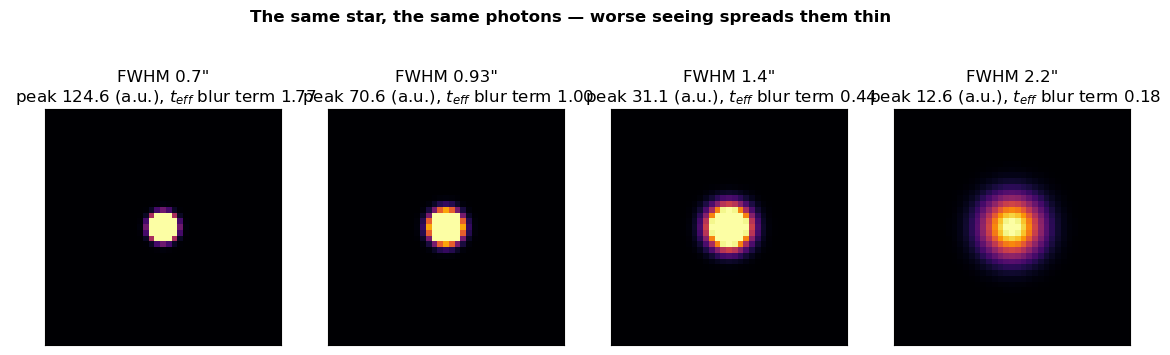

In [2]:
PIXEL_SCALE = 0.263   # arcsec/pixel (DECam)
half = 20             # cutout half-size in pixels

y, x = np.mgrid[-half:half+1, -half:half+1]
r2 = (x**2 + y**2) * PIXEL_SCALE**2

seeings = [0.7, 0.93, 1.4, 2.2]     # 0.93" = the i-band fiducial ("par")
fig, axes = plt.subplots(1, len(seeings), figsize=(14, 4))
for ax, s in zip(axes, seeings):
    sigma = s / 2.355
    star = np.exp(-r2 / (2 * sigma**2))
    star /= star.sum()               # same total photons in every panel
    ax.imshow(star, cmap='inferno', vmin=0, vmax=0.012)
    ax.set_xticks([]); ax.set_yticks([])
    rel = blur_term(s, 'i')
    ax.set_title(f'FWHM {s}\"\n peak {star.max()*1e3:.1f} (a.u.), $t_{{eff}}$ blur term {rel:.2f}')
fig.suptitle('The same star, the same photons — worse seeing spreads them thin', y=1.04, fontweight='bold')
plt.show()

At 2.2″ seeing the star's peak is ~10× fainter than at 0.7″ — faint sources simply vanish into sky noise. A schedule that collects its $z$-band exposures during the best seeing and saves cloudy-but-calm hours for less demanding work is *worth real survey time*.

## 2. Blur across the survey: band by band

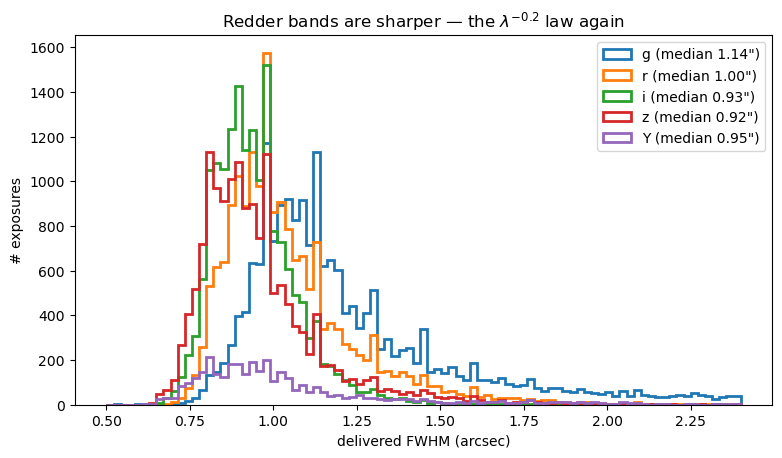

In [3]:
BANDS = ['g', 'r', 'i', 'z', 'Y']
bins = np.linspace(0.5, 2.4, 90)
fig, ax = plt.subplots(figsize=(9, 4.8))
for b in BANDS:
    v = f.loc[f['filter'] == b, 'qc_fwhm']
    ax.hist(v, bins=bins, histtype='step', lw=2, label=f'{b} (median {v.median():.2f}\")')
ax.set_xlabel('delivered FWHM (arcsec)'); ax.set_ylabel('# exposures')
ax.set_title('Redder bands are sharper — the $\\lambda^{-0.2}$ law again')
ax.legend(); plt.show()

## 3. Blur across the sky and through the year

Two maps a scheduler could exploit: *where* (declination — fields that transit far from zenith are always seen through more air) and *when* (season).

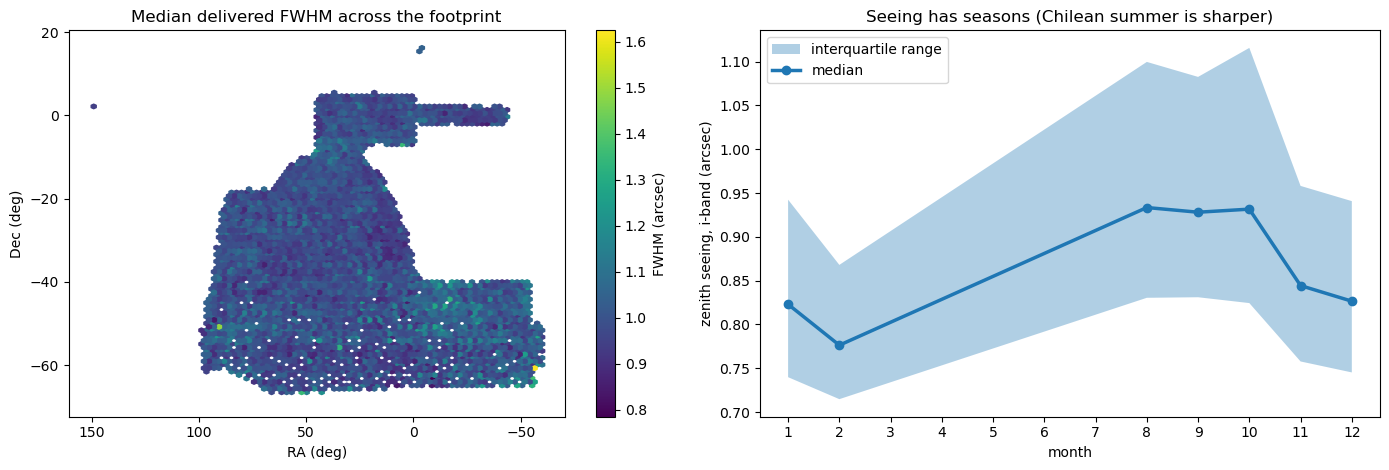

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

hb = axes[0].hexbin(f['ra_wrapped'], f['dec'], C=f['qc_fwhm'], reduce_C_function=np.median,
                    gridsize=90, cmap='viridis', mincnt=5)
axes[0].set_xlabel('RA (deg)'); axes[0].set_ylabel('Dec (deg)')
axes[0].set_title('Median delivered FWHM across the footprint')
axes[0].invert_xaxis()
fig.colorbar(hb, ax=axes[0], label='FWHM (arcsec)')

mon = f.groupby(f['dt'].dt.month)['zenith_i'].quantile([.25, .5, .75]).unstack()
axes[1].fill_between(mon.index, mon[.25], mon[.75], alpha=.35, label='interquartile range')
axes[1].plot(mon.index, mon[.5], 'o-', lw=2.5, label='median')
axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel('month'); axes[1].set_ylabel('zenith seeing, i-band (arcsec)')
axes[1].set_title('Seeing has seasons (Chilean summer is sharper)')
axes[1].legend()
plt.tight_layout(); plt.show()

## 4. The airmass trap — a scheduler hides its own physics

Theory says pointing away from zenith looks through more atmosphere: $\mathrm{FWHM}\propto X^{0.6}$. So *fit that exponent from the data*:

In [5]:
slope_pooled = np.polyfit(np.log(f['airmass']), np.log(f['fwhm_i']), 1)[0]
print(f'pooled fit of log FWHM vs log airmass: exponent = {slope_pooled:+.2f}   (theory: +0.6 ?!)')

pooled fit of log FWHM vs log airmass: exponent = -0.23   (theory: +0.6 ?!)


**Negative!** Taken at face value, images get *sharper* away from zenith. Physics is not broken — the *sampling* is. Hypothesis: DES's human-tuned scheduler pointed at high-airmass fields **preferentially when the atmosphere was good**. If true, atmosphere quality and airmass are anti-correlated in the log — a selection effect.

Test it, then remove it (compare like with like *within a night*):

In [6]:
sel = np.corrcoef(np.log(f['zenith_i']), np.log(f['airmass']))[0, 1]
print(f'corr(log zenith seeing, log airmass) = {sel:+.2f}  ->  the scheduler DID select')

# within-night fixed effects: subtract each night's mean before fitting
ln_f = np.log(f['fwhm_i']);  ln_x = np.log(f['airmass'])
g = f.groupby('night')
ln_f_c = ln_f - g['fwhm_i'].transform(lambda s: np.log(s).mean())
ln_x_c = ln_x - g['airmass'].transform(lambda s: np.log(s).mean())
slope_within = float((ln_f_c*ln_x_c).sum() / (ln_x_c**2).sum())
print(f'within-night exponent = {slope_within:+.2f}  ->  the physical law re-emerges')

corr(log zenith seeing, log airmass) = -0.36  ->  the scheduler DID select
within-night exponent = +0.23  ->  the physical law re-emerges


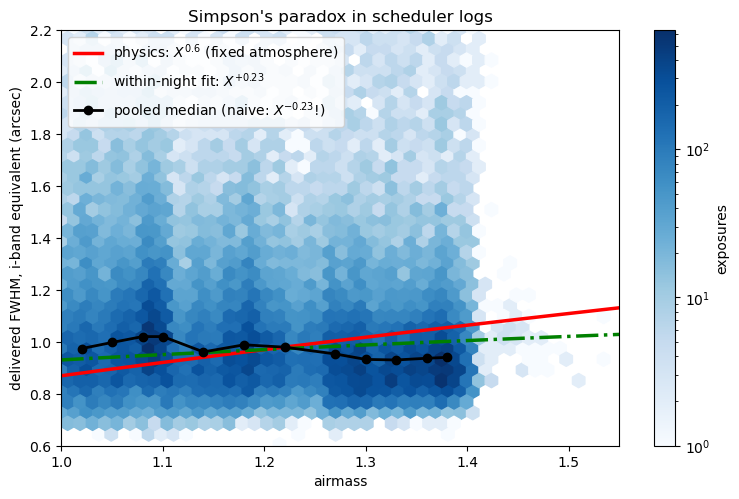

In [7]:
x_grid = np.linspace(1.0, 1.55, 100)
anchor = float(np.median(f['zenith_i'])) * 1.2**0.6

qbins = np.quantile(f['airmass'], np.linspace(0, 1, 13))
qmid, qmed = [], []
for lo, hi in zip(qbins[:-1], qbins[1:]):
    m = (f['airmass'] >= lo) & (f['airmass'] < hi)
    if m.sum() > 50:
        qmid.append(f.loc[m, 'airmass'].median()); qmed.append(f.loc[m, 'fwhm_i'].median())

fig, ax = plt.subplots(figsize=(9, 5.4))
hb = ax.hexbin(f['airmass'], f['fwhm_i'], gridsize=70, cmap='Blues', bins='log', mincnt=1)
ax.plot(x_grid, anchor*(x_grid/1.2)**0.6, 'r-', lw=2.5, label='physics: $X^{0.6}$ (fixed atmosphere)')
ax.plot(x_grid, anchor*(x_grid/1.2)**slope_within, 'g-.', lw=2.5,
        label=f'within-night fit: $X^{{{slope_within:+.2f}}}$')
ax.plot(qmid, qmed, 'ko-', lw=2, label=f'pooled median (naive: $X^{{{slope_pooled:+.2f}}}$!)')
ax.set_xlim(1, 1.55); ax.set_ylim(0.6, 2.2)
ax.set_xlabel('airmass'); ax.set_ylabel('delivered FWHM, i-band equivalent (arcsec)')
ax.set_title("Simpson's paradox in scheduler logs")
ax.legend(loc='upper left'); fig.colorbar(hb, label='exposures'); plt.show()

### Why this matters far beyond blur

This is the cleanest evidence in our data that **logged observations are not experiments**. The logging scheduler's policy is baked into every correlation. Consequences:

- **For evaluation:** comparing schedulers on raw logged outcomes is confounded — a metric must isolate the *decision* quality (e.g., the airmass factor) from the *conditions* (zenith seeing).
- **For RL:** this is precisely the off-policy problem. An agent trained naively on this data could learn "high airmass → sharp images." Conservative offline methods (CQL — our other reading) exist to keep the learned policy honest about what the data does and doesn't support.

## 5. So: who is to blame for blur? The decomposition

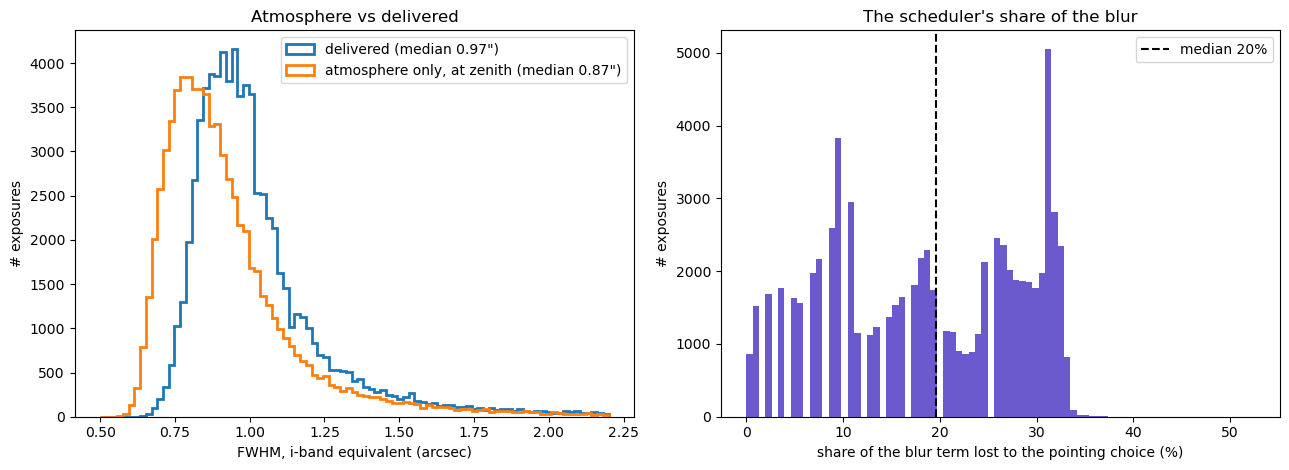

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

bins = np.linspace(0.5, 2.2, 90)
axes[0].hist(f['fwhm_i'], bins=bins, histtype='step', lw=2,
             label=f"delivered (median {f['fwhm_i'].median():.2f}\")")
axes[0].hist(f['zenith_i'], bins=bins, histtype='step', lw=2,
             label=f"atmosphere only, at zenith (median {f['zenith_i'].median():.2f}\")")
axes[0].set_xlabel('FWHM, i-band equivalent (arcsec)'); axes[0].set_ylabel('# exposures')
axes[0].set_title('Atmosphere vs delivered'); axes[0].legend()

cost = 1 - airmass_blur_factor(f['airmass'])**-2     # t_eff blur value lost to pointing
axes[1].hist(100*cost, bins=80, color='slateblue')
axes[1].axvline(100*np.median(cost), color='k', ls='--',
                label=f'median {100*np.median(cost):.0f}%')
axes[1].set_xlabel("share of the blur term lost to the pointing choice (%)")
axes[1].set_ylabel('# exposures'); axes[1].set_title("The scheduler's share of the blur")
axes[1].legend()
plt.tight_layout(); plt.show()

## Takeaways

1. **Blur intuition:** the $(\cdot)^2$ in the metric is peak-brightness physics; 2″ seeing makes a star ~5× harder to detect than 0.9″.
2. **The scheduler's blur lever is airmass** — the median exposure gives up ~20% of its blur term to the pointing choice. That's the part a schedule metric should judge.
3. **Selection bias is real and measurable in our data** — the pooled blur-airmass relation has the *wrong sign* because the behavior policy chose when to go high. Any schedule evaluation (and any offline RL training) must account for this.
4. Toolkit: `zenith_seeing`, `airmass_blur_factor`, `to_reference_band`, `blur_decomposition` in `skai_metrics.blur`.

**Next:** notebook 03 aggregates exposure quality into *schedule* scores and ranks 600+ real DES nights.